 - https://www.kaggle.com/competitions/ventilator-pressure-prediction

# Project Description

## Background and Motivation

Mechanical ventilation is a life-saving medical procedure used when patients are unable to breathe adequately on their own. In such cases, a ventilator delivers oxygen into the patient’s lungs through a tube inserted into the windpipe while the patient is sedated.

However, mechanical ventilation is a highly clinician-intensive process. This limitation became especially evident during the early stages of the COVID-19 pandemic, when the demand for ventilators and trained medical staff dramatically increased worldwide.

At the same time, developing and testing new ventilator control strategies is extremely costly and complex, particularly before reaching clinical trial stages. High-quality computational simulators offer a promising solution to reduce these barriers by enabling safe and cost-effective experimentation.

---

## Limitations of Current Approaches

Current ventilator simulators are typically trained as ensembles of models, where each model corresponds to a specific lung configuration.  

However, lung mechanics do not vary discretely — they form a **continuous physiological space**. This means that a more general, parametric modeling approach is required to effectively capture variations in patient-specific lung attributes.

In clinical practice, most ventilators rely on classical **PID (Proportional–Integral–Derivative) controllers**. While effective, these controllers may struggle to generalize across patients with significantly different lung characteristics.

---

## Research Objective

 The central hypothesis is that:

> Neural networks and deep learning models can better generalize across lungs with varying compliance and resistance compared to traditional PID controllers.

In this project, we simulate a ventilator connected to a sedated patient’s lung and develop a data-driven model capable of predicting airway pressure dynamics.

The model explicitly incorporates:

- **Lung compliance (C)** — representing how easily the lung expands  
- **Lung resistance (R)** — representing airway restriction  

By accounting for these physiological parameters, the model aims to adapt to different lung conditions.

---

## Expected Impact

A successful parametric simulator could:

- Reduce the cost of developing new ventilator control strategies  
- Enable safer experimentation without immediate clinical trials  
- Facilitate adaptive algorithms that personalize ventilation to individual patients  
- Reduce clinician workload in high-demand scenarios  
- Improve global accessibility to advanced ventilator treatments  

Ultimately, this work contributes to advancing intelligent, adaptive medical systems capable of improving patient care in both emergency and routine clinical settings.

---

## Project Scope

This Master’s project focuses on:

- Modeling ventilator–lung interaction as a time-series prediction problem  
- Leveraging deep learning architectures to simulate airway pressure  
- Evaluating generalization across varying lung compliance and resistance settings  
- Comparing data-driven approaches with traditional control paradigms  

The goal is to investigate whether modern machine learning techniques can provide robust and scalable solutions for mechanical ventilation modeling.


# Ventilator Dataset Description

## Experimental Setup

The ventilator data used in this competition was produced using a **modified open-source ventilator** connected to an artificial **bellows test lung** through a respiratory circuit.

The system consists of:

- **Two control inputs** (manipulated variables)
- **One state variable** (airway pressure) to predict

### Control Inputs

1. **`u_in` — Inspiratory Valve Control**
   - Continuous variable ranging from **0 to 100**
   - Represents the percentage that the **inspiratory solenoid valve** is open
   - `0` → Valve fully closed (no air enters)
   - `100` → Valve fully open (maximum air enters)

2. **`u_out` — Expiratory Valve Control**
   - Binary variable:  
     - `0` → Valve closed  
     - `1` → Valve open (air released)

### Target Variable
- **`pressure`** — Airway pressure (cmH₂O)
- This is the variable the model must predict.

## Time Series Structure
- Each time series corresponds to **one breath (~3 seconds)**.
- Each row represents a **single time step within a breath**.
- The dataset is structured so that:
  - Rows are timesteps
  - Groups of 80 timesteps form one breath

# Dataset Columns
### Identifiers
- **`id`**  
  Globally unique identifier for each time step across the entire file.

- **`breath_id`**  
  Identifier grouping time steps belonging to the same breath.

### Lung Attributes
- **`R` — Resistance (cmH₂O / L / s)**  
  Indicates how restricted the airway is.  

  Physically:  
  - Change in pressure per change in airflow  
  - Higher `R` → Harder to move air  

  Intuition:  
  Blowing up a balloon through a straw.  
  A smaller straw diameter → Higher resistance → Harder to blow.

- **`C` — Compliance (mL / cmH₂O)**  
  Indicates how easily the lung expands.

  Physically:  
  - Change in volume per change in pressure  
  - Higher `C` → Easier expansion  

  Intuition:  
  A thinner balloon expands more easily → Higher compliance.

### Time Information

- **`time_step`**  
  The actual timestamp of the measurement within a breath.

### Control Signals
- **`u_in`**  
  Inspiratory valve opening percentage (0–100).

- **`u_out`**  
  Expiratory valve state (0 or 1).

### Target Variable
- **`pressure`**  
  Measured airway pressure in the respiratory circuit (cmH₂O).

## Learning Objective
Given:

- Lung attributes (`R`, `C`)
- Control signals (`u_in`, `u_out`)
- Time evolution within a breath

The task is to predict the **airway pressure at each timestep**.
## Evaluation

The competition is scored using the **Mean Absolute Error (MAE)** between the predicted and actual pressures **during the inspiratory phase of each breath**.

The expiratory phase is **not scored**.

The evaluation metric is defined as:

$$
\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} \left| \hat{y}_i - y_i \right|
$$

where:

- $\hat{y}$ is the vector of **predicted pressures**
- $y$ is the vector of **actual pressures**
- $N$ is the total number of evaluated timesteps across all breaths in the test set (inspiratory phase only)

Only inspiratory timesteps contribute to the final score.
## Mean Absolute Error (MAE)

### Definition

The **Mean Absolute Error (MAE)** is a regression metric that measures the average magnitude of prediction errors without considering their direction.

It is defined as:

$$
\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} \left| \hat{y}_i - y_i \right|
$$

where:

- $\hat{y}_i$ is the predicted value  
- $y_i$ is the true value  
- $N$ is the total number of evaluated samples  

MAE computes the average of the absolute differences between predictions and actual values.

---

## Why MAE is Used in This Project

In the ventilator simulation task, the objective is to predict **airway pressure** at each timestep of a breath. The use of MAE is motivated by several important considerations:

### 1. Interpretability

MAE is expressed in the same units as the target variable (cmH₂O).  
This makes it directly interpretable from a clinical perspective:

- An MAE of 1.5 means the model is, on average, 1.5 cmH₂O away from the true pressure.

---

### 2. Equal Penalization of Errors

Unlike Mean Squared Error (MSE), MAE:

- Does **not square** the error
- Penalizes all deviations linearly

This is important because:

- Large pressure deviations are undesirable
- But extreme penalization (as in MSE) may overemphasize rare outliers

MAE provides a balanced evaluation of performance across all timesteps.

---

### 3. Robustness to Outliers

Since errors are not squared, MAE is **more robust to occasional extreme values** than MSE.

In physiological systems:

- Noise
- Sudden valve changes
- Measurement artifacts  

may introduce occasional spikes in pressure.  
MAE prevents such spikes from disproportionately influencing the evaluation.

---

### 4. Alignment with Competition Objective

The competition explicitly evaluates predictions using MAE **during the inspiratory phase only**.  

Therefore, optimizing MAE during training ensures that the model directly optimizes the same objective used for final evaluation.

---

## Comparison with Other Metrics

| Metric | Penalization | Sensitivity to Outliers | Interpretability |
|--------|-------------|--------------------------|------------------|
| MAE    | Linear      | Moderate                 | High             |
| MSE    | Quadratic   | High                     | Medium           |
| RMSE   | Quadratic   | High                     | High             |

For this project, MAE offers the best trade-off between stability, interpretability, and alignment with evaluation criteria.

---

## Practical Implication in This Work

Minimizing MAE means that the model:

- Accurately tracks airway pressure dynamics  
- Reduces average deviation across inspiratory timesteps  
- Maintains stable predictions across different lung configurations  

This makes MAE a clinically meaningful and technically appropriate metric for evaluating ventilator simulation models.
# Time Series Analysis

## Time Series in General

A **time series** is a sequence of observations collected at successive time intervals.  
Unlike standard tabular data, time series data exhibits:

- **Temporal dependency** — past values influence future values  
- **Sequential structure** — order matters  
- **Dynamic behavior** — patterns evolve over time  

Mathematically, a time series can be represented as:

$$
x_1, x_2, x_3, \dots, x_T
$$

where each observation is indexed by time.

### Key Characteristics of Time Series

1. **Autocorrelation**  
   Current values often depend on previous values.

2. **Trend**  
   Long-term increase or decrease over time.

3. **Seasonality**  
   Repeating patterns at fixed intervals.

4. **Noise**  
   Random fluctuations or measurement errors.

Because of temporal dependence, time series modeling requires specialized methods such as:

- ARIMA models  
- State-space models  
- Recurrent Neural Networks (RNNs)  
- LSTMs and GRUs  
- Transformer-based architectures  

Traditional machine learning models that assume independent samples are generally not suitable without additional feature engineering.

---

# Time Series in This Project

In this project, each **breath** represents a short multivariate time series of approximately 3 seconds.

Each breath consists of:

- 80 timesteps  
- Multiple input features (control signals and lung attributes)  
- One target variable (airway pressure)

### Multivariate Time Series

The data is **multivariate**, meaning that at each timestep we observe multiple variables:

- Control inputs (`u_in`, `u_out`)
- Lung attributes (`R`, `C`)
- Timestamp
- Airway pressure (target)

Thus, each breath can be represented as:

$$
X_t \in \mathbb{R}^d
$$

where:
- $t = 1, \dots, 80$
- $d$ is the number of input features

The objective is to model the mapping:

$$
(X_1, X_2, ..., X_{80}) \rightarrow (y_1, y_2, ..., y_{80})
$$

This is a **sequence-to-sequence regression problem**.

---

## Dynamic Nature of Ventilator Data

Unlike many classical time series:

- There is **no long-term trend**
- There is **no seasonality**
- Each sequence is independent from the others

However, within each breath:

- Airway pressure depends on previous pressure values
- It depends on valve control inputs
- It depends on lung mechanics (resistance and compliance)

This makes the system a **forced dynamical system**, where:

- Inputs = valve controls  
- System parameters = lung attributes  
- Output = airway pressure  

The temporal dependency is governed by physical respiratory mechanics.

---

## Why Sequential Models Are Necessary

If we ignore time order:

- The physical dynamics of airflow would be lost  
- Pressure evolution could not be modeled correctly  

Models such as **LSTMs** are appropriate because they:

- Capture short-term temporal dependencies  
- Maintain internal memory of previous timesteps  
- Model nonlinear dynamic relationships  

In this context, the neural network learns an approximation of the underlying physiological system.

---

# Summary

This project treats mechanical ventilation as a **multivariate, short-horizon, nonlinear time series prediction problem**.

Each breath:

- Is independent from others  
- Contains strong internal temporal structure  
- Represents a physical dynamical process  

Therefore, time-aware deep learning architectures are essential to accurately model airway pressure evolution.
## Fundamental Components of Time Series

Understanding time series requires identifying the structural components that govern temporal behavior. The four most important characteristics are autocorrelation, trend, seasonality, and noise.

---

### 1. Autocorrelation

**Definition**

Autocorrelation refers to the dependency between a value in the series and its past values.  
In other words, the current observation is statistically related to previous observations.

Mathematically, a simple autoregressive process can be written as:

$$
x_t = \phi x_{t-1} + \epsilon_t
$$

where:
- $\phi$ measures dependence on the previous value
- $\epsilon_t$ is random noise

If $\phi \neq 0$, the series exhibits autocorrelation.

---

**Example 1 — Temperature**

If today’s temperature is high, tomorrow’s temperature is likely to be high as well.  
The system has inertia — it does not change abruptly.

---

**Example 2 — Ventilator Pressure (This Project)**

Airway pressure at time $t$ depends on:

- The pressure at time $t-1$
- The airflow introduced in previous timesteps
- Lung mechanics (R and C)

Pressure does not instantly jump to a new value; it evolves dynamically.  
This is strong short-term autocorrelation.

---

### 2. Trend

**Definition**

A trend represents a long-term systematic increase or decrease in the series.

It can be modeled as:

$$
x_t = \beta t + \epsilon_t
$$

where $\beta$ indicates the direction and magnitude of growth.

---

**Example 1 — Economic Growth**

GDP over decades typically shows an upward trend.

---

**Example 2 — Medical Monitoring**

A patient’s blood pressure gradually increasing over months may indicate a trend.

---

**In This Project**

Within a single breath (~3 seconds), there is no long-term trend.  
However, during the inspiratory phase, pressure increases smoothly — a short-term local trend driven by airflow.

---

### 3. Seasonality

**Definition**

Seasonality refers to repeating patterns occurring at fixed intervals.

Formally:

$$
x_t = x_{t+s}
$$

where $s$ is the seasonal period.

---

**Example 1 — Electricity Demand**

Electricity consumption peaks every evening.  
This is daily seasonality.

---

**Example 2 — Retail Sales**

Sales increase every December.  
This is yearly seasonality.

---

**In This Project**

There is no classical seasonality across breaths.  
However, within each breath:

- Inspiration phase
- Expiration phase

This creates a structured repeated pattern across samples.  
Each breath follows a similar physiological cycle.

---

### 4. Noise

**Definition**

Noise represents random fluctuations that cannot be explained by the underlying structure.

Usually modeled as:

$$
\epsilon_t \sim \mathcal{N}(0, \sigma^2)
$$

Noise can arise from:
- Measurement errors
- Sensor precision limits
- Unmodeled external influences

---

**Example 1 — Financial Markets**

Stock prices contain random fluctuations due to unpredictable events.

---

**Example 2 — Ventilator Data**

Airway pressure measurements may include:

- Sensor noise
- Micro valve delays
- Numerical simulation imperfections

These fluctuations are not deterministic and must be handled by robust models.

---

## Summary in Context of This Project

| Component        | Present in This Dataset? | Explanation |
|------------------|--------------------------|------------|
| Autocorrelation  | Strong                   | Pressure depends on previous pressure values |
| Trend            | Local (within breath)    | Pressure increases during inspiration |
| Seasonality      | Structured pattern       | Repeated inspiratory/expiratory cycles |
| Noise            | Present                  | Measurement and system variability |

The ventilator problem is therefore best described as a **short-horizon nonlinear dynamical time series with strong autocorrelation and structured cyclic behavior**.
# Model Interpretability with SHAP

## Why Model Interpretability Matters

In medical and physiological modeling, predictive performance alone is not sufficient.  
Understanding **why** a model makes a certain prediction is equally important.

In this ventilator simulation project, the model predicts airway pressure based on:

- Control inputs (`u_in`, `u_out`)
- Lung attributes (`R`, `C`)
- Temporal evolution within a breath

Because the model is based on deep learning (e.g., LSTMs), it behaves as a **black box**.  
To ensure reliability and clinical relevance, we need tools that explain the model’s behavior.

One such tool is **SHAP**.

---

# What is SHAP?

**SHAP (SHapley Additive exPlanations)** is a model-agnostic interpretability method based on cooperative game theory.

It assigns each feature a contribution value that explains how much that feature influenced a specific prediction.

SHAP is based on **Shapley values**, originally developed in game theory to fairly distribute rewards among players depending on their contribution to a collective outcome.

In a machine learning setting:

- Each **feature** is a “player”
- The **prediction** is the “payout”
- SHAP computes how much each feature contributed to moving the prediction away from the average prediction

---

## Mathematical Idea

A prediction can be decomposed as:

$$
f(x) = \phi_0 + \sum_{i=1}^{d} \phi_i
$$

where:

- $f(x)$ is the model prediction
- $\phi_0$ is the average prediction (baseline)
- $\phi_i$ is the SHAP value for feature $i$
- $d$ is the number of features

Each $\phi_i$ represents the contribution of feature $i$ to that specific prediction.

---

# Why SHAP is Useful in This Project

## 1. Understanding Feature Importance

SHAP can help answer:

- Is airway pressure more influenced by `u_in` or lung compliance `C`?
- Does resistance `R` significantly affect early timesteps?
- Does `u_out` mainly impact the expiratory phase?

This helps validate whether the model learned physiologically meaningful relationships.

---

## 2. Time-Dependent Feature Contributions

Because this is a time-series model, we can:

- Compute SHAP values at each timestep
- Observe how feature importance evolves during inspiration and expiration

For example:

- During inspiration → `u_in` should have strong positive contribution
- During expiration → `u_out` should dominate

If SHAP reveals unrealistic behavior, it may indicate model overfitting.

---

## 3. Clinical Trust and Validation

In medical contexts:

- Interpretability increases trust
- Black-box predictions without explanation are risky

SHAP allows us to verify that:

- Higher resistance leads to higher predicted pressure
- Higher compliance leads to smoother pressure curves

This aligns predictions with physical laws of respiratory mechanics.

---

# How SHAP Can Be Applied Here

For deep learning models (e.g., LSTMs), SHAP provides:

- **DeepExplainer** (for neural networks)
- **KernelExplainer** (model-agnostic, slower but flexible)

The workflow would be:

1. Train the LSTM model
2. Select a subset of breaths as background data
3. Compute SHAP values for selected validation samples
4. Visualize feature contributions

---

## Example Interpretations

### Global Interpretation
- Average feature importance across all breaths
- Identify most influential variables overall

### Local Interpretation
- For a single breath:
  - Why did the model predict high pressure at timestep 20?
  - Which feature caused that spike?

### Temporal Interpretation
- Plot SHAP values across 80 timesteps
- Observe phase-dependent importance patterns

---

# Advantages of SHAP in This Context

- Theoretically grounded (game theory)
- Provides both local and global explanations
- Model-agnostic
- Handles nonlinear feature interactions

---

# Limitations

- Computationally expensive for deep models
- Interpretation becomes complex for high-dimensional time series
- Requires careful aggregation across timesteps

---

# Summary

In this project, SHAP serves as a tool to:

- Interpret the deep learning model
- Validate physiological consistency
- Increase transparency of predictions
- Support scientific and clinical credibility

By applying SHAP, we move from a purely predictive model to an interpretable and trustworthy system capable of explaining ventilator pressure dynamics.


# IMPORTS

In [17]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import time
import warnings
import gc
import multiprocessing
import os,random, math, psutil, pickle
from datetime import datetime
import matplotlib.pyplot as plt
from datetime import datetime

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#              sklearn
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler, normalize
from sklearn.model_selection import train_test_split, GroupKFold, KFold
import tensorflow as tf
! conda env export > environment.yml

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
#              Keras
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
import tensorflow.keras.backend as K
from tensorflow.keras.losses import MeanSquaredError as mse_loss
from tensorflow.keras.utils import *
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.models import Model, Sequential, model_from_json
from tensorflow.keras import regularizers

from tensorflow.keras.layers import Dense, LSTM ,Bidirectional
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint

import shap
import numpy as np




# Set Notebook Options

In [18]:

print("Tensorflow version " + tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

Tensorflow version 2.20.0
Num GPUs Available:  1


# Functions

In [19]:

# # Functions
#from google.colab import drive
#drive.mount('/content/gdrive', force_remount=True)
#!ls "/content/gdrive/My Drive/kaggle"
def add_features(df):#022
    df['area'] = df['time_step'] * df['u_in']
    df['area'] = df.groupby('breath_id')['area'].cumsum() 
    df['u_in_cumsum'] = (df['u_in']).groupby(df['breath_id']).cumsum()
    df['u_in_lag1'] = df.groupby('breath_id')['u_in'].shift(1)
    df['u_out_lag1'] = df.groupby('breath_id')['u_out'].shift(1)
    df['u_in_lag_back1'] = df.groupby('breath_id')['u_in'].shift(-1)
    df['u_out_lag_back1'] = df.groupby('breath_id')['u_out'].shift(-1)
    df['u_in_lag2'] = df.groupby('breath_id')['u_in'].shift(2)
    df['u_out_lag2'] = df.groupby('breath_id')['u_out'].shift(2)
    df['u_in_lag_back2'] = df.groupby('breath_id')['u_in'].shift(-2)
    df['u_out_lag_back2'] = df.groupby('breath_id')['u_out'].shift(-2)
    df['u_in_lag3'] = df.groupby('breath_id')['u_in'].shift(3)
    df['u_out_lag3'] = df.groupby('breath_id')['u_out'].shift(3)
    df['u_in_lag_back3'] = df.groupby('breath_id')['u_in'].shift(-3)
    df['u_out_lag_back3'] = df.groupby('breath_id')['u_out'].shift(-3)
    df['u_in_lag4'] = df.groupby('breath_id')['u_in'].shift(4)
    df['u_out_lag4'] = df.groupby('breath_id')['u_out'].shift(4)
    df['u_in_lag_back4'] = df.groupby('breath_id')['u_in'].shift(-4)
    df['u_out_lag_back4'] = df.groupby('breath_id')['u_out'].shift(-4)
    df = df.fillna(0)
    """
    df['breath_id__u_in__max'] = df.groupby(['breath_id'])['u_in'].transform('max')
    df['breath_id__u_out__max'] = df.groupby(['breath_id'])['u_out'].transform('max')
    
    df['u_in_diff1'] = df['u_in'] - df['u_in_lag1']
    df['u_out_diff1'] = df['u_out'] - df['u_out_lag1']
    df['u_in_diff2'] = df['u_in'] - df['u_in_lag2']
    df['u_out_diff2'] = df['u_out'] - df['u_out_lag2']
    
    df['breath_id__u_in__diffmax'] = df.groupby(['breath_id'])['u_in'].transform('max') - df['u_in']
    df['breath_id__u_in__diffmean'] = df.groupby(['breath_id'])['u_in'].transform('mean') - df['u_in']
    
    df['breath_id__u_in__diffmax'] = df.groupby(['breath_id'])['u_in'].transform('max') - df['u_in']
    df['breath_id__u_in__diffmean'] = df.groupby(['breath_id'])['u_in'].transform('mean') - df['u_in']
    
    df['u_in_diff3'] = df['u_in'] - df['u_in_lag3']
    df['u_out_diff3'] = df['u_out'] - df['u_out_lag3']
    df['u_in_diff4'] = df['u_in'] - df['u_in_lag4']
    df['u_out_diff4'] = df['u_out'] - df['u_out_lag4']
    df['cross']= df['u_in']*df['u_out']
    df['cross2']= df['time_step']*df['u_out']

    for feature in ['u_in','cross','cross2','area','u_in_cumsum','u_in_diff1','u_in_diff2','u_in_diff3','u_in_diff4'] :
      data = df[feature].astype(float).values
      s = data
      fft = np.fft.fft(s)
      fftfreq = np.fft.fftfreq(len(s))
      #df['u_in_fft'] = fft
      df[feature+'_fft_freq'] = fftfreq 
    """   
    df['R'] = df['R'].astype(str)
    df['C'] = df['C'].astype(str)
    df['R__C'] = df["R"].astype(str) + '__' + df["C"].astype(str)
    df = pd.get_dummies(df)
    return df



# Load data files

In [20]:

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Load data files
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
start_time = time.time()
path = "./data/"
start_time = time.time()
dataset = pd.read_csv(path + 'train.csv')
print('Load files took  %s seconds' % (time.time() - start_time))

# print datasets info
display(dataset.info())



Load files took  3.625993251800537 seconds
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6036000 entries, 0 to 6035999
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   breath_id  int64  
 2   R          int64  
 3   C          int64  
 4   time_step  float64
 5   u_in       float64
 6   u_out      int64  
 7   pressure   float64
dtypes: float64(3), int64(5)
memory usage: 368.4 MB


None

# TARGET EXTRACTION

In [21]:
# --------------------------------------------------
# Reshape target to 3D array for LSTM
# --------------------------------------------------
#targets = train[['pressure']].to_numpy().reshape(-1, 80, 1)

# Data Exploration to be inclusdd

# Data Pre-processing

In [22]:

dataset = add_features(dataset)
display(dataset.info())
dataset.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6036000 entries, 0 to 6035999
Data columns (total 39 columns):
 #   Column           Dtype  
---  ------           -----  
 0   id               int64  
 1   breath_id        int64  
 2   time_step        float64
 3   u_in             float64
 4   u_out            int64  
 5   pressure         float64
 6   area             float64
 7   u_in_cumsum      float64
 8   u_in_lag1        float64
 9   u_out_lag1       float64
 10  u_in_lag_back1   float64
 11  u_out_lag_back1  float64
 12  u_in_lag2        float64
 13  u_out_lag2       float64
 14  u_in_lag_back2   float64
 15  u_out_lag_back2  float64
 16  u_in_lag3        float64
 17  u_out_lag3       float64
 18  u_in_lag_back3   float64
 19  u_out_lag_back3  float64
 20  u_in_lag4        float64
 21  u_out_lag4       float64
 22  u_in_lag_back4   float64
 23  u_out_lag_back4  float64
 24  R_20             bool   
 25  R_5              bool   
 26  R_50             bool   
 27  C_10        

None

,id,breath_id,time_step,u_in,u_out,pressure,area,u_in_cumsum,u_in_lag1,u_out_lag1,u_in_lag_back1,u_out_lag_back1,u_in_lag2,u_out_lag2,u_in_lag_back2,u_out_lag_back2,u_in_lag3,u_out_lag3,u_in_lag_back3,u_out_lag_back3,u_in_lag4,u_out_lag4,u_in_lag_back4,u_out_lag_back4,R_20,R_5,R_50,C_10,C_20,C_50,R__C_20__10,R__C_20__20,R__C_20__50,R__C_50__10,R__C_50__20,R__C_50__50,R__C_5__10,R__C_5__20,R__C_5__50
0,1,1,0.00000,0.08333,0,5.83749,0.00000,0.08333,0.00000,0.00000,18.38304,0.00000,0.00000,0.00000,22.50928,0.00000,0.00000,0.00000,22.80882,0.00000,0.00000,0.00000,25.35585,0.00000,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False
1,2,1,0.03365,18.38304,0,5.90779,0.61863,18.46638,0.08333,0.00000,22.50928,0.00000,0.00000,0.00000,22.80882,0.00000,0.00000,0.00000,25.35585,0.00000,0.00000,0.00000,27.25987,0.00000,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False
2,3,1,0.06751,22.50928,0,7.87625,2.13833,40.97565,18.38304,0.00000,22.80882,0.00000,0.08333,0.00000,25.35585,0.00000,0.00000,0.00000,27.25987,0.00000,0.00000,0.00000,27.12749,0.00000,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False
3,4,1,0.10154,22.80882,0,11.74287,4.45439,63.78448,22.50928,0.00000,25.35585,0.00000,18.38304,0.00000,27.25987,0.00000,0.08333,0.00000,27.12749,0.00000,0.00000,0.00000,26.80773,0.00000,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False
4,5,1,0.13576,25.35585,0,12.23499,7.89659,89.14033,22.80882,0.00000,27.25987,0.00000,22.50928,0.00000,27.12749,0.00000,18.38304,0.00000,26.80773,0.00000,0.08333,0.00000,27.86472,0.00000,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False


# Dataset Split train,val,test

In [23]:
# Correct Sequence-Preserving Split
# train 50% of the data, validate 10%, and test on the remaining 40%
# Entire breaths stay together
# No timestep from one breath appears in multiple splits
# No leakage across sequences
# Proper LSTM training

# Ensure sorted
dataset = dataset.sort_values(["breath_id", "time_step"])

# Get unique sequences
breaths = dataset["breath_id"].unique()
n = len(breaths)

train_end = int(0.5 * n)
val_end   = int(0.6 * n)

train_ids = breaths[:train_end]
val_ids   = breaths[train_end:val_end]
test_ids  = breaths[val_end:]

train = dataset[dataset["breath_id"].isin(train_ids)].copy()
val   = dataset[dataset["breath_id"].isin(val_ids)].copy()
test  = dataset[dataset["breath_id"].isin(test_ids)].copy()

print(train["breath_id"].nunique(),
      val["breath_id"].nunique(),
      test["breath_id"].nunique())

# Extra Safety Check
assert set(train["breath_id"]).isdisjoint(val["breath_id"])
assert set(train["breath_id"]).isdisjoint(test["breath_id"])
assert set(val["breath_id"]).isdisjoint(test["breath_id"])

print("No sequence leakage ")



37725 7545 30180
No sequence leakage 


# Make targets

In [ ]:

targets = dataset['pressure'].values.reshape(-1, 80)

n = targets.shape[0]

train_end = int(0.5 * n)
val_end   = int(0.6 * n)

y_train = targets[:train_end]
y_val   = targets[train_end:val_end]
y_test  = targets[val_end:]

print("Train Targets shape:", y_train.shape)
print("Val Targets shape:", y_val.shape)
print("Test Targets shape:", y_test.shape)

#================================
# Free memory
#================================
del targets
gc.collect()


Train Targets shape: (37725, 80)
Val Targets shape: (7545, 80)
Test Targets shape: (30180, 80)


# Filter columns for training

In [26]:

#================================
# Filter columns for training
#================================
dataset.drop(['pressure', 'id', 'breath_id','time_step'], axis=1, inplace=True)
features = list(dataset.columns)
print('Number of feature columns =', len(features))

#================================
# Free memory
#================================
del dataset
gc.collect()

Number of feature columns = 35


42770

##  SCALING ( try other scalers)

In [27]:

# --------------------------------------------------
# SCALING
# --------------------------------------------------
RS = RobustScaler()
train = RS.fit_transform(train)
test  = RS.transform(test)
val   = RS.transform(val)



## RESHAPE train,val,test TO SEQUENCES

In [28]:

# reshape train and test to 3D array for LSTM
# --------------------------------------------------
# RESHAPE TO SEQUENCES
# --------------------------------------------------
train = train.reshape(-1, 80, train.shape[-1])
val   = val.reshape(-1, 80, val.shape[-1])
test  = test.reshape(-1, 80, test.shape[-1]) 

print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)





Train shape: (37725, 80, 39)
Val shape: (7545, 80, 39)
Test shape: (30180, 80, 39)


In [32]:
print("Train Targets shape:", y_train.shape)
print("Val Targets shape:", y_val.shape)
print("Test Targets shape:", y_test.shape)

Train Targets shape: (37725, 80)
Val Targets shape: (7545, 80)
Test Targets shape: (30180, 80)


# MODEL

In [29]:

# --------------------------------------------------
# MODEL
# --------------------------------------------------
model = Sequential()

model.add(Bidirectional(
    LSTM(512, return_sequences=True),
    input_shape=(80, train.shape[2])
))

model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Bidirectional(LSTM(64, return_sequences=True)))

model.add(TimeDistributed(Dense(64)))
model.add(LeakyReLU(negative_slope=0.1))

model.add(TimeDistributed(Dense(32)))
model.add(LeakyReLU(negative_slope=0.1))

model.add(TimeDistributed(Dense(1)))

# --------------------------------------------------
# COMPILE Add AdamW
# --------------------------------------------------

model.compile(
    optimizer='adam',
    loss='mae',
    metrics=['mae']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional) │ (None, 80, 1024)       │     2,260,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 80, 128)        │       557,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 80, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 80, 64)         │         8,256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 80, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 80, 32)         │         2,080 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 80, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 80, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,927,745 (11.17 MB)

 Trainable params: 2,927,745 (11.17 MB)

 Non-trainable params: 0 (0.00 B)

# CALLBACKS

In [30]:

# --------------------------------------------------
# CALLBACKS
# --------------------------------------------------
lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)


# TRAIN

In [33]:
print("Train Targets shape:", y_train.shape)
print("Val Targets shape:", y_val.shape)
print("Test Targets shape:", y_test.shape)

Train Targets shape: (37725, 80)
Val Targets shape: (7545, 80)
Test Targets shape: (30180, 80)


In [34]:

# --------------------------------------------------
# TRAIN
# --------------------------------------------------
history = model.fit(
    train,
    y_train,
    validation_data=(val, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[lr, early_stop],
    verbose=1
)


Epoch 1/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 39s 132ms/step - loss: 0.4631 - mae: 0.4631 - val_loss: 0.4705 - val_mae: 0.4705 - learning_rate: 0.0010
Epoch 2/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 35s 118ms/step - loss: 0.3109 - mae: 0.3109 - val_loss: 0.1671 - val_mae: 0.1671 - learning_rate: 0.0010
Epoch 3/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 36s 121ms/step - loss: 0.2654 - mae: 0.2654 - val_loss: 0.3016 - val_mae: 0.3016 - learning_rate: 0.0010
Epoch 4/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 35s 119ms/step - loss: 0.1710 - mae: 0.1710 - val_loss: 0.1393 - val_mae: 0.1393 - learning_rate: 0.0010
Epoch 5/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 38s 130ms/step - loss: 0.1585 - mae: 0.1585 - val_loss: 0.1043 - val_mae: 0.1043 - learning_rate: 0.0010
Epoch 6/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 40s 136ms/step - loss: 0.1815 - mae: 0.1815 - val_loss: 0.1086 - val_mae: 0.1086 - learning_rate: 0.0010
Epoch 7/10
295/295 ━━━━━━━━━━━━━━━━━━━━ 38s 128ms/step - loss: 0.1505 - mae: 0.1505 - val_loss: 0.0827 - val_mae: 0.0827 - learnin

# EVALUATION

In [35]:

# --------------------------------------------------
# EVALUATION
# --------------------------------------------------
val_loss, val_mae = model.evaluate(val, y_val, verbose=0)
print(f"\nValidation MAE: {val_mae:.5f}")

test_loss, test_mae = model.evaluate(test, y_test, verbose=0)
print(f"\nTest MAE: {test_mae:.5f}")


Validation MAE: 0.06284

Test MAE: 0.06047


# PLOTS

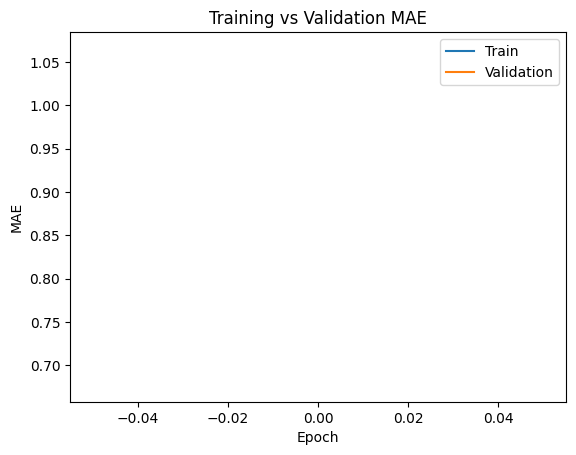

472/472 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step


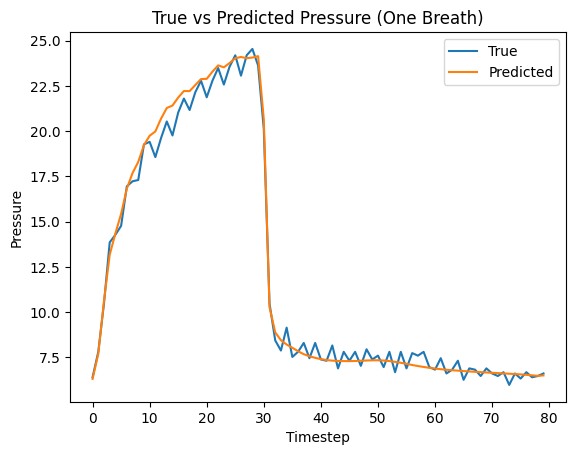

472/472 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step


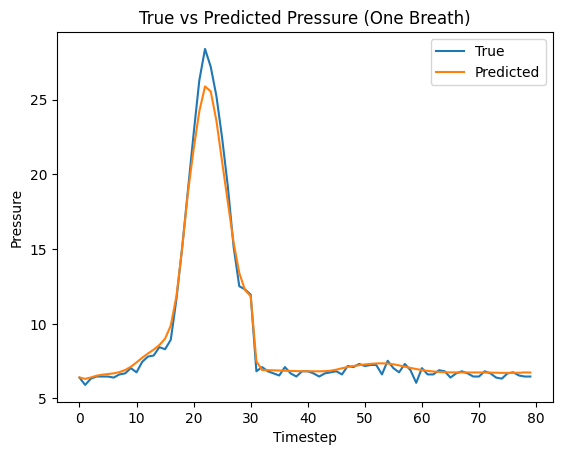

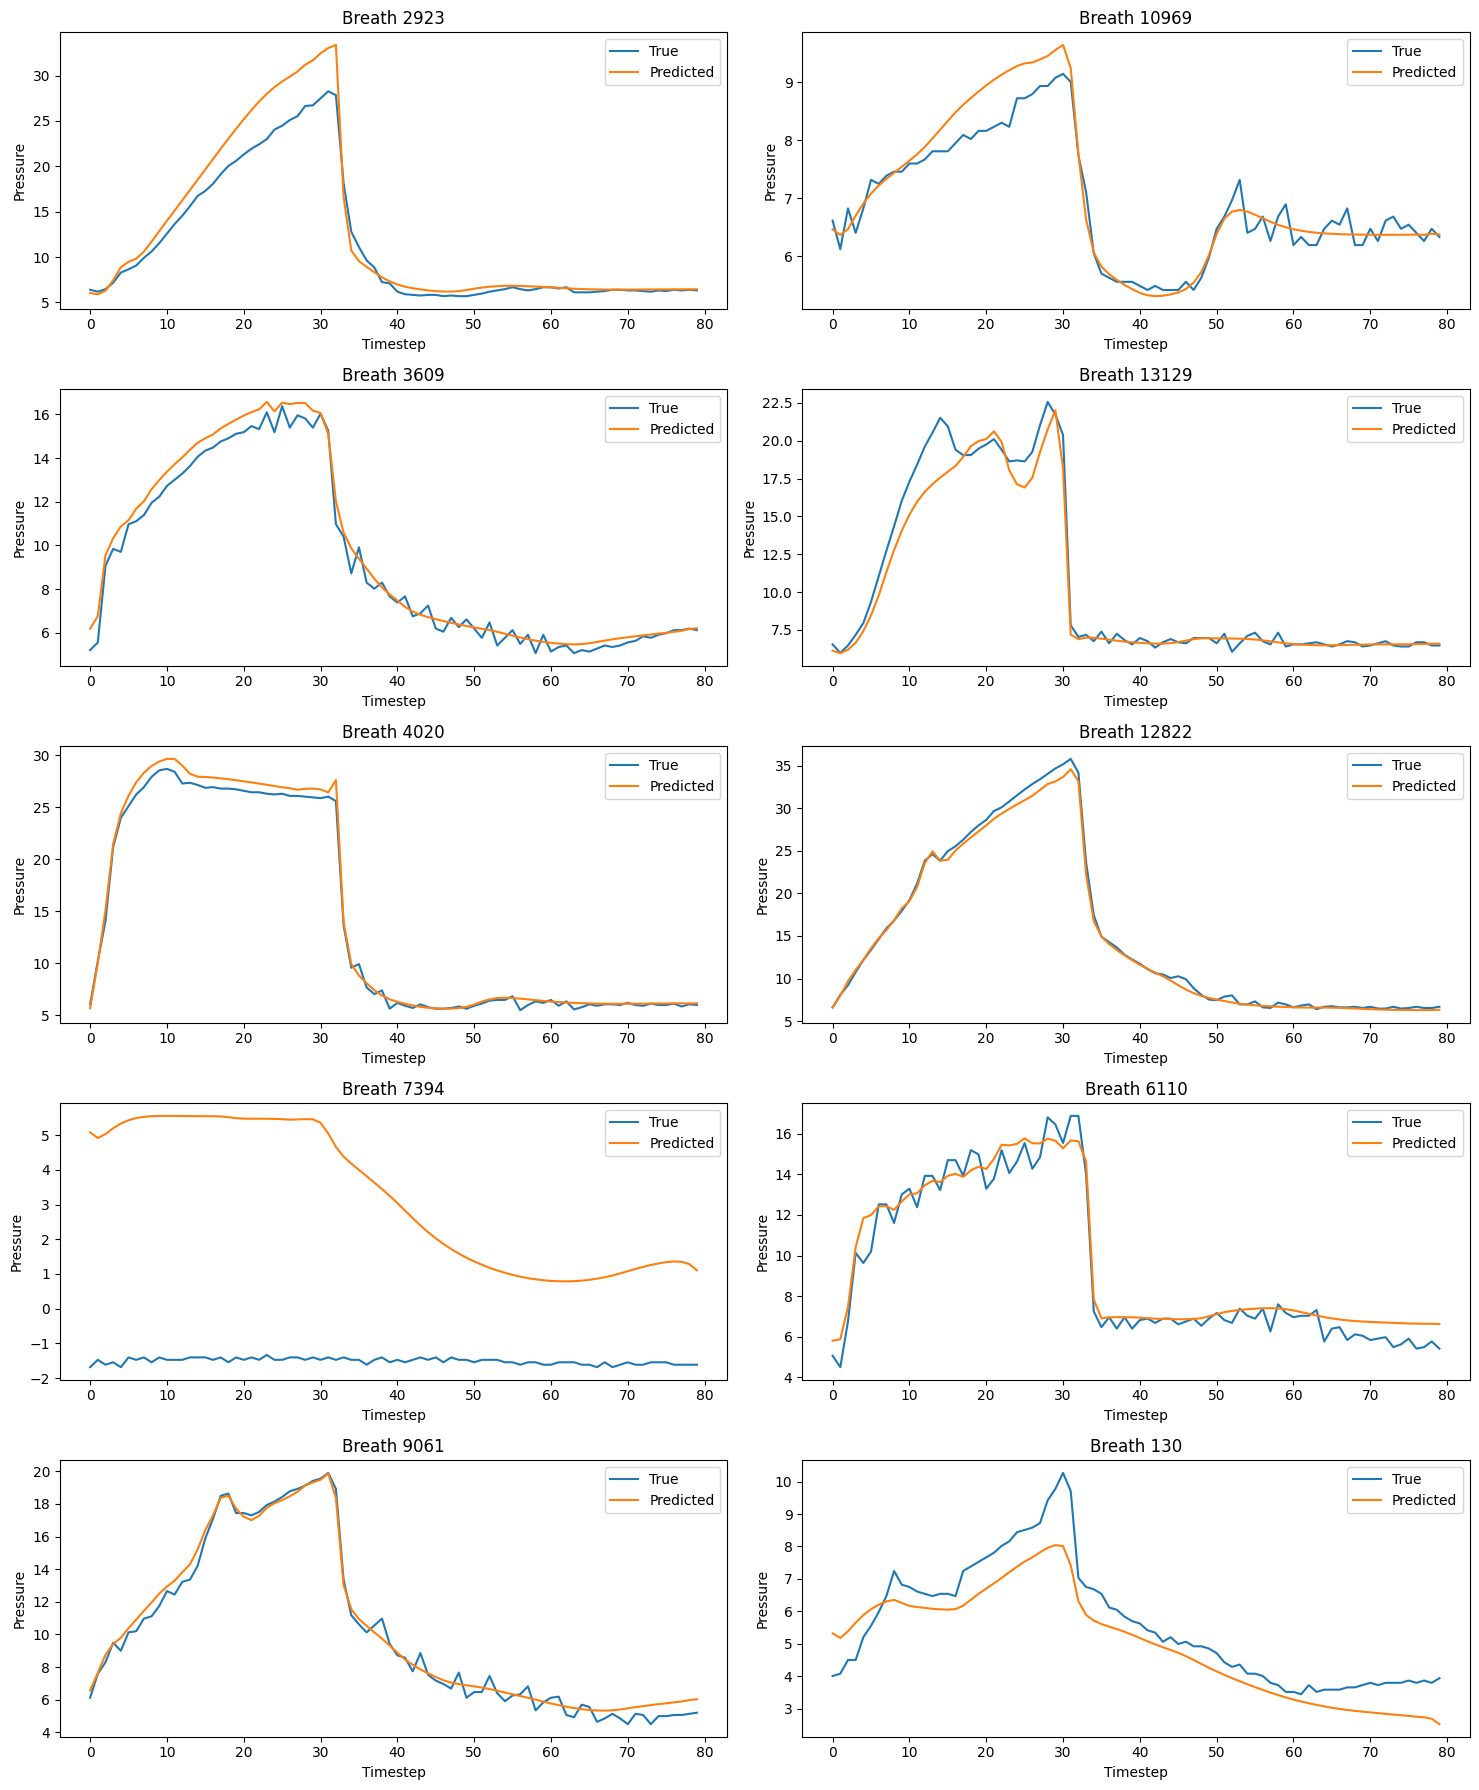

In [ ]:

# --------------------------------------------------
# PLOT TRAINING HISTORY
# --------------------------------------------------
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend(["Train", "Validation"])
plt.show()

# --------------------------------------------------
# PREDICTIONS on validation set
# --------------------------------------------------
y_pred = model.predict(val)

# Plot one validation breath
sample = 0

plt.figure()
plt.plot(y_valid[sample].flatten())
plt.plot(y_pred[sample].flatten())
plt.title("True vs Predicted Pressure (One Breath)")
plt.xlabel("Timestep")
plt.ylabel("Pressure")
plt.legend(["True", "Predicted"])
plt.show()

# Plot one validation breath
sample = 10

plt.figure()
plt.plot(y_valid[sample].flatten())
plt.plot(y_pred[sample].flatten())
plt.title("True vs Predicted Pressure (One Breath)")
plt.xlabel("Timestep")
plt.ylabel("Pressure")
plt.legend(["True", "Predicted"])
plt.show()


num_samples = 10
indices = np.random.choice(len(y_valid), num_samples, replace=False)

plt.figure(figsize=(15, 18))

for i, idx in enumerate(indices):
    plt.subplot(5, 2, i + 1)
    plt.plot(y_valid[idx].flatten())
    plt.plot(y_pred[idx].flatten())
    plt.title(f"Breath {idx}")
    plt.xlabel("Timestep")
    plt.ylabel("Pressure")
    plt.legend(["True", "Predicted"])

plt.tight_layout()
plt.show()




# SHAP

In [ ]:

# Select small background sample
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

# Select samples to explain
samples_to_explain = X_valid[:10]
samples_to_explain
explainer = shap.DeepExplainer(model, background)

shap_values = explainer.shap_values(samples_to_explain)

#  shap_values = shap_values[0]  # shape: (10, 80, n_features)
# Plot SHAP values for the first sample
shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[0][0], feature_names=features)
#   Visualizing SHAP Across 80 Timesteps
mean_shap = np.mean(np.abs(shap_values), axis=0)  
# shape: (80, n_features)
#  Plot SHAP Over Time for One Feature

import matplotlib.pyplot as plt

feature_idx = 0
plt.figure(figsize=(10, 5))
plt.plot(mean_shap[:, feature_idx])
plt.title("SHAP Value Across 80 Timesteps (u_in)")
plt.xlabel("Timestep")
plt.ylabel("Mean |SHAP value|")
plt.show()
# Global Feature Importance
global_importance = np.mean(mean_shap, axis=0)

plt.figure(figsize=(10,5))
plt.bar(range(len(global_importance)), global_importance)
plt.title("Global Feature Importance (SHAP)")
plt.xlabel("Feature Index")
plt.ylabel("Mean |SHAP|")
plt.show()

# we can replace index with:
# plt.xticks(range(len(features)), features, rotation=90)
# SHAP Heatmap (Feature x Time)
plt.figure(figsize=(12,6))
plt.imshow(mean_shap.T, aspect='auto')
plt.colorbar()
plt.xlabel("Timestep")
plt.ylabel("Feature Index")
plt.title("SHAP Heatmap (Feature x Time)")
plt.show()

AssertionError: The model output must be a vector or a single value!

In [36]:
import numpy as np
import shap
import tensorflow as tf

# Select small background sample
background = train[np.random.choice(train.shape[0], 100, replace=False)]

# Samples to explain
samples_to_explain = val[:10]

In [37]:
# Compute SHAP per Output Timestep
n_timesteps = train.shape[1]      # should be 80
n_features  = train.shape[2]

all_shap = []  # will collect SHAP values per timestep

for t in range(n_timesteps):

    print(f"Explaining timestep {t+1}/{n_timesteps}")

    wrapped_model = tf.keras.Model(
        inputs=model.input,
        outputs=model.output[:, t]
    )

    explainer = shap.DeepExplainer(wrapped_model, background)

    shap_values = explainer.shap_values(samples_to_explain)

    # shap_values shape: (samples, 80, n_features)
    all_shap.append(shap_values)

Explaining timestep 1/80


AttributeError: The layer sequential_1 has never been called and thus has no defined input.